# Detección de toxicidad en comentarios en español con Transformers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

## Propósito

En este proyecto construiremos un clasificador binario que determine si un comentario en español es tóxico o no tóxico. El trabajo sigue la estructura de `1-transformers-from-scratch.ipynb`, pero cambia el dominio, los datos y la pregunta de análisis.

La pregunta central es: **¿puede un transformer pequeño, entrenado desde cero sobre comentarios en español, reconocer señales lingüísticas de toxicidad sin depender de un modelo preentrenado?** Además de medir el desempeño, examinaremos qué tipos de comentarios confunden al modelo.

### Decisiones del proyecto
- Usaremos el dataset multilingüe de TextDetox y conservaremos solamente los ejemplos en español.
- Entrenaremos el tokenizador y el transformer desde cero, como en el notebook de referencia.
- Compararemos dos variantes: una con una cabeza de atención y otra con cuatro cabezas.
- Incluiremos EDA, baseline TF-IDF, matriz de confusión, métricas por clase y revisión cualitativa de errores.

### Referencias
- Dataset: https://huggingface.co/datasets/textdetox/multilingual_toxicity_dataset
- Dataset original en español: https://github.com/microsoft/Clandestino
- [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- [Natural Language Processing with Transformers](https://www.oreilly.com/library/view/natural-language-processing/9781098103242/)
- Notebook guía: `Sesion2/1-transformers-from-scratch.ipynb`

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print('Entorno Colab:', IN_COLAB)

Entorno Colab: True


In [2]:
!test '{IN_COLAB}' = 'True' && pip -q install datasets tokenizers transformers scikit-learn seaborn torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.4 MB/s eta 0:00:00


## 1. Carga y preparación de los datos

El dataset contiene ejemplos tóxicos y no tóxicos en varios idiomas. Como el idioma forma parte del problema, no debemos mezclar lenguas: primero filtraremos español y después revisaremos las etiquetas.

In [3]:
import os
import numpy as np
import pandas as pd
from datasets import load_dataset

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
DATASET_NAME = 'textdetox/multilingual_toxicity_dataset'

# El repositorio publica una configuración independiente por idioma.
raw = load_dataset(DATASET_NAME, trust_remote_code=True)
if 'es' in raw:
    dataset = raw['es']
elif 'spa' in raw:
    dataset = raw['spa']
elif 'train' in raw:
    dataset = raw['train']
else:
    raise ValueError(f'No se encontró una configuración española. Configuraciones disponibles: {list(raw.keys())}')

print(dataset)
print('Columnas:', dataset.column_names)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'textdetox/multilingual_toxicity_dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'textdetox/multilingual_toxicity_dataset' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md:   0%|          | 0.00/8.91k [00:00<?, ?B/s]

data/en-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  267kB            

data/en-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/ru-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  388kB            

...

Generating he split:   0%|          | 0/2011 [00:00<?, ? examples/s]

Generating hin split:   0%|          | 0/4363 [00:00<?, ? examples/s]

Generating tt split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating ja split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'toxic'],
    num_rows: 5000
})
Columnas: ['text', 'toxic']


In [4]:
# El dataset publicado usa text/toxic; esta comprobación hace explícito el contrato esperado.
required_columns = {'text', 'toxic'}
missing = required_columns.difference(dataset.column_names)
if missing:
    raise ValueError(f'Faltan columnas esperadas: {missing}. Columnas encontradas: {dataset.column_names}')

df = dataset.to_pandas()
language_column = next((c for c in ['language', 'lang', 'locale'] if c in df.columns), None)
if language_column is not None:
    language_values = df[language_column].astype(str).str.lower()
    df = df[language_values.isin(['es', 'spa', 'spanish', 'es-es'])].copy()

def normalize_label(value):
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    if isinstance(value, str):
        value = value.strip().lower()
        if value in {'true', 'toxic', 'tóxico', 'yes'}: return 1
        if value in {'false', 'non-toxic', 'not toxic', 'no tóxico', 'no'}: return 0
    return int(float(value))

df['label_id'] = df['toxic'].map(normalize_label).astype(int)
df['text'] = df['text'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df = df[df['text'].str.len() > 0].drop_duplicates('text').reset_index(drop=True)
print(f'Ejemplos en español después de limpiar: {len(df):,}')
df[['text', 'toxic', 'label_id']].head()

Ejemplos en español después de limpiar: 5,000


,text,toxic,label_id
0,A este tambien lo habia que echar porque era u...,1,1
1,la mañana coincidió que charlando de mis labio...,1,1
2,El vídeo del que todo el mundo habla XD « Jord...,1,1
3,del peor error de mexico queda claro que fue u...,1,1
4,antes de irme a trabajar la abuela me folla,1,1


## 2. EDA: ¿cómo son los comentarios?

Antes de entrenar, revisaremos balance de clases, longitud, vocabulario y señales superficiales. Esta exploración es importante porque la toxicidad suele expresarse en textos cortos, con insultos, repeticiones, mayúsculas o símbolos; esas características también pueden producir atajos indeseados.

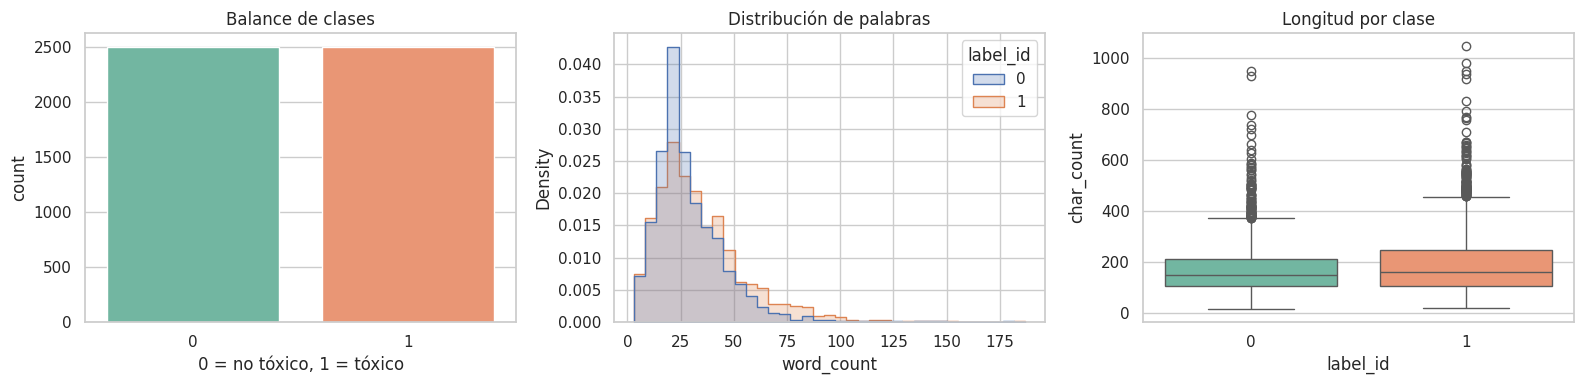

,word_count,char_count,uppercase_ratio,has_url
label_id,,,,
0,28.991,169.244,0.026,0.035
1,34.181,191.672,0.021,0.000


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()
df['uppercase_ratio'] = df['text'].map(lambda x: sum(c.isupper() for c in x) / max(sum(c.isalpha() for c in x), 1))
df['has_url'] = df['text'].str.contains(r'http|www\.', case=False, regex=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='label_id', ax=axes[0], palette='Set2')
axes[0].set_title('Balance de clases')
axes[0].set_xlabel('0 = no tóxico, 1 = tóxico')
sns.histplot(data=df, x='word_count', hue='label_id', bins=35, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Distribución de palabras')
sns.boxplot(data=df, x='label_id', y='char_count', ax=axes[2], palette='Set2')
axes[2].set_title('Longitud por clase')
plt.tight_layout()
plt.show()

display(df.groupby('label_id')[['word_count', 'char_count', 'uppercase_ratio', 'has_url']].mean().round(3))

In [6]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def most_common_words(frame, label, n=20):
    words = ' '.join(frame.loc[frame.label_id == label, 'text']).lower().split()
    words = [w.strip('.,!?¡¿:;()[]{}"') for w in words if len(w) > 2 and w not in ENGLISH_STOP_WORDS]
    return Counter(words).most_common(n)

print('Palabras frecuentes en comentarios no tóxicos:')
print(most_common_words(df, 0))
print('\nPalabras frecuentes en comentarios tóxicos:')
print(most_common_words(df, 1))

display(df.groupby('label_id')[['word_count', 'char_count']].describe().round(2))

Palabras frecuentes en comentarios no tóxicos:
[('que', 2708), ('los', 1437), ('una', 893), ('por', 669), ('las', 635), ('para', 599), ('del', 490), ('como', 475), ('más', 278), ('pero', 256), ('son', 248), ('sus', 231), ('ser', 192), ('hay', 184), ('nos', 167), ('entre', 158), ('todos', 155), ('sin', 153), ('muy', 149), ('todo', 139)]

Palabras frecuentes en comentarios tóxicos:
[('que', 3980), ('los', 1711), ('una', 886), ('por', 803), ('las', 617), ('como', 568), ('para', 549), ('del', 489), ('son', 434), ('pero', 341), ('más', 329), ('sus', 270), ('porque', 236), ('unos', 231), ('eres', 218), ('ser', 210), ('mierda', 209), ('les', 188), ('sin', 186), ('todos', 185)]


word_count                                             char_count  \
              count   mean    std  min   25%   50%   75%    max      count   
label_id                                                                     
0            2500.0  28.99  16.58  3.0  18.0  25.0  36.0  179.0     2500.0   
1            2500.0  34.18  21.30  3.0  19.0  29.0  44.0  187.0     2500.0   

                                                             
            mean     std   min    25%    50%    75%     max  
label_id                                                     
0         169.24   95.54  15.0  106.0  147.0  212.0   951.0  
1         191.67  123.31  19.0  106.0  161.0  246.0  1049.0

### Interpretación inicial

La distribución anterior servirá como hipótesis de trabajo. Si las clases tienen longitudes muy diferentes, el modelo podría aprender longitud en vez de toxicidad. Por eso reportaremos resultados por clase y revisaremos ejemplos donde el texto sea corto, largo o contenga señales superficiales.

## 3. División estratificada y baseline TF-IDF

Antes del transformer, construiremos una referencia barata con TF-IDF y regresión logística. Esta línea base permite responder si la arquitectura neuronal realmente agrega valor.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label_id'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label_id'], random_state=42)
print({name: len(part) for name, part in [('train', train_df), ('validation', val_df), ('test', test_df)]})

baseline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
baseline.fit(train_df['text'], train_df['label_id'])
baseline_pred = baseline.predict(test_df['text'])
print(classification_report(test_df['label_id'], baseline_pred, target_names=['no tóxico', 'tóxico']))

{'train': 3500, 'validation': 750, 'test': 750}
              precision    recall  f1-score   support

   no tóxico       0.80      0.80      0.80       375
      tóxico       0.80      0.80      0.80       375

    accuracy                           0.80       750
   macro avg       0.80      0.80      0.80       750
weighted avg       0.80      0.80      0.80       750



## 4. Tokenizador entrenado sobre el corpus

Al igual que en el notebook de referencia, entrenaremos un tokenizador Byte-Level BPE usando únicamente los textos de entrenamiento. La longitud máxima se fija en 128 tokens para que el experimento sea viable en Colab y para estudiar un escenario realista de comentarios cortos.

In [8]:
from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer
from tqdm.auto import tqdm

base_tokenizer = AutoTokenizer.from_pretrained('gpt2')
train_texts = train_df['text'].tolist()
tokenizer = base_tokenizer.train_new_from_iterator(
    (train_texts[i:i + 32] for i in range(0, len(train_texts), 32)),
    vocab_size=12000,
    initial_alphabet=list(ByteLevel.alphabet()),
    new_special_tokens=['[PAD]'],
)
tokenizer.pad_token = '[PAD]'
MAX_LEN = 128
print('Tamaño del vocabulario:', len(tokenizer))
print(tokenizer('Este comentario es una prueba.', max_length=MAX_LEN, truncation=True, padding='max_length'))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tamaño del vocabulario: 12000
{'input_ids': [3023, 5415, 286, 324, 7526, 15, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [9]:
sample = 'No estoy de acuerdo contigo, pero podemos discutirlo.'
encoded = tokenizer(sample, max_length=20, truncation=True, padding='max_length')
print('Tokens:', encoded.tokens())
print('IDs:', encoded['input_ids'])
print('Reconstrucción:', tokenizer.decode(encoded['input_ids']))

Tokens: ['No', 'Ġestoy', 'Ġde', 'Ġacuerdo', 'Ġcontigo', ',', 'Ġpero', 'Ġpodemos', 'Ġdiscu', 'tir', 'lo', '.', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
IDs: [464, 1561, 267, 2800, 3705, 13, 430, 2328, 11479, 1085, 360, 15, 1, 1, 1, 1, 1, 1, 1, 1]
Reconstrucción: No estoy de acuerdo contigo, pero podemos discutirlo.[PAD][PAD][PAD][PAD][PAD][PAD][PAD][PAD]


## 5. Dataset de PyTorch y positional embeddings

Convertiremos cada comentario a `input_ids`, `attention_mask` y etiqueta. La máscara evita que el modelo considere los tokens de padding como contenido lingüístico.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

class ToxicityDataset(Dataset):
    def __init__(self, frame, tokenizer, max_len=128):
        self.frame = frame.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        encoded = self.tokenizer(row['text'], max_length=self.max_len, truncation=True, padding='max_length', return_tensors='pt')
        return {'input_ids': encoded['input_ids'].squeeze(0), 'attention_mask': encoded['attention_mask'].squeeze(0), 'label': torch.tensor(row['label_id'], dtype=torch.long), 'text': row['text']}

In [11]:
class SinusoidPE(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        dimension = torch.arange(d_model).unsqueeze(0)
        div_term = torch.exp(-np.log(10000.0) * (2 * (dimension // 2)) / d_model)
        angles = position * div_term
        encoding = torch.zeros(max_len, d_model)
        encoding[:, 0::2] = torch.sin(angles[:, 0::2])
        encoding[:, 1::2] = torch.cos(angles[:, 1::2])
        self.register_buffer('encoding', encoding.unsqueeze(0), persistent=False)
    def forward(self, x):
        return x + self.encoding[:, :x.size(1), :]

class TokenAndPosEmbedding(nn.Module):
    def __init__(self, max_len, embed_dim, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = SinusoidPE(max_len, embed_dim)
    def forward(self, input_ids):
        return self.position_embedding(self.token_embedding(input_ids))

## 6. Multi-Head Attention y bloque Transformer

La atención calcula qué tokens deben influir en la representación de cada posición. Usaremos la definición del referente:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Después de la atención aplicaremos conexión residual, normalización y una red feed-forward. A diferencia del ejemplo original, usaremos `mean pooling` en la clasificación; así el número de parámetros no crece linealmente con toda la longitud de la secuencia.

In [12]:
import math
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        if embed_dim % num_heads != 0: raise ValueError('embed_dim debe ser divisible por num_heads')
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.output = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)
    def split_heads(self, x):
        batch, seq_len, embed_dim = x.shape
        return x.view(batch, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
    def forward(self, x, attention_mask):
        q, k, v = self.split_heads(self.query(x)), self.split_heads(self.key(x)), self.split_heads(self.value(x))
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        key_mask = attention_mask[:, None, None, :].bool()
        scores = scores.masked_fill(~key_mask, -1e4)
        weights = self.dropout(torch.softmax(scores, dim=-1))
        context = torch.matmul(weights, v).transpose(1, 2).contiguous()
        context = context.view(x.size(0), x.size(1), -1)
        return self.output(context), weights

In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim=256, dropout=0.15):
        super().__init__()
        self.attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.feed_forward = nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(ff_dim, embed_dim))
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, attention_mask):
        attended, weights = self.attention(self.norm1(x), attention_mask)
        x = x + self.dropout(attended)
        x = x + self.dropout(self.feed_forward(self.norm2(x)))
        return x, weights

class ToxicityTransformer(nn.Module):
    def __init__(self, vocab_size, max_len, embed_dim=96, num_heads=4, num_classes=2):
        super().__init__()
        self.embedding = TokenAndPosEmbedding(max_len, embed_dim, vocab_size)
        self.transformer = TransformerBlock(embed_dim, num_heads)
        self.classifier = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 64), nn.GELU(), nn.Dropout(0.2), nn.Linear(64, num_classes))
    def forward(self, input_ids, attention_mask, return_attention=False):
        x = self.embedding(input_ids)
        x, weights = self.transformer(x, attention_mask)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        logits = self.classifier(pooled)
        return (logits, weights) if return_attention else logits

In [14]:
train_data = ToxicityDataset(train_df, tokenizer, MAX_LEN)
val_data = ToxicityDataset(val_df, tokenizer, MAX_LEN)
test_data = ToxicityDataset(test_df, tokenizer, MAX_LEN)
batch_size = 32 if IN_COLAB else 16
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0)
batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in batch.items() if hasattr(value, 'shape')})

{'input_ids': (32, 128), 'attention_mask': (32, 128), 'label': (32,)}


## 7. Entrenamiento y comparación de arquitecturas

Compararemos cuatro y una cabeza de atención manteniendo constantes los demás elementos. La comparación no busca declarar un ganador universal: busca observar cómo cambia el comportamiento cuando el modelo puede atender simultáneamente a más relaciones entre tokens.

In [15]:
from sklearn.metrics import f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, predictions, targets = 0.0, [], []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        with torch.set_grad_enabled(training):
            logits = model(input_ids, attention_mask)
            loss = F.cross_entropy(logits, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
        total_loss += loss.item() * len(labels)
        predictions.extend(logits.argmax(1).detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), f1_score(targets, predictions, zero_division=0), np.array(targets), np.array(predictions)

def train_model(num_heads, epochs=4):
    torch.manual_seed(42)
    model = ToxicityTransformer(len(tokenizer), MAX_LEN, embed_dim=96, num_heads=num_heads).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    history = []
    for epoch in range(epochs):
        train_loss, train_f1, _, _ = run_epoch(model, train_loader, optimizer)
        val_loss, val_f1, _, _ = run_epoch(model, val_loader)
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'train_f1': train_f1, 'val_loss': val_loss, 'val_f1': val_f1})
        print(f'Cabezas={num_heads} | época={epoch + 1} | train F1={train_f1:.3f} | val F1={val_f1:.3f}')
    return model, pd.DataFrame(history)

model_1, history_1 = train_model(num_heads=1)
model_4, history_4 = train_model(num_heads=4)

Dispositivo: cuda
Cabezas=1 | época=1 | train F1=0.571 | val F1=0.457
Cabezas=1 | época=2 | train F1=0.629 | val F1=0.661
Cabezas=1 | época=3 | train F1=0.670 | val F1=0.702
Cabezas=1 | época=4 | train F1=0.703 | val F1=0.645
Cabezas=4 | época=1 | train F1=0.573 | val F1=0.478
Cabezas=4 | época=2 | train F1=0.633 | val F1=0.672
Cabezas=4 | época=3 | train F1=0.684 | val F1=0.696
Cabezas=4 | época=4 | train F1=0.701 | val F1=0.660


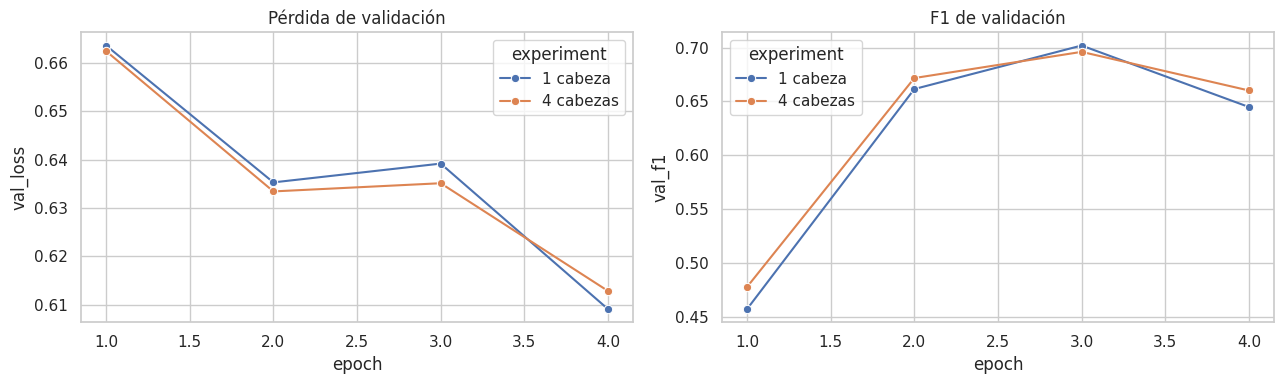

,modelo,accuracy,precision_toxica,recall_toxica,f1_toxica
0,TF-IDF,0.800,0.798,0.803,0.801
1,1 cabeza,0.669,0.703,0.587,0.640
2,4 cabezas,0.664,0.696,0.581,0.634


In [16]:
histories = pd.concat([history_1.assign(experiment='1 cabeza'), history_4.assign(experiment='4 cabezas')])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=histories, x='epoch', y='val_loss', hue='experiment', marker='o', ax=axes[0])
axes[0].set_title('Pérdida de validación')
sns.lineplot(data=histories, x='epoch', y='val_f1', hue='experiment', marker='o', ax=axes[1])
axes[1].set_title('F1 de validación')
plt.tight_layout()
plt.show()

test_results = []
for name, model in [('TF-IDF', None), ('1 cabeza', model_1), ('4 cabezas', model_4)]:
    if model is None:
        y_true, y_pred = test_df['label_id'].to_numpy(), baseline_pred
    else:
        _, _, y_true, y_pred = run_epoch(model, test_loader)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', zero_division=0)
    test_results.append({'modelo': name, 'accuracy': accuracy_score(y_true, y_pred), 'precision_toxica': precision, 'recall_toxica': recall, 'f1_toxica': f1})
results_df = pd.DataFrame(test_results).sort_values('f1_toxica', ascending=False)

# Se formatean solo las columnas numéricas para evitar incompatibilidades entre versiones de pandas.
display(results_df.style.format(precision=3))

## 8. Evaluación detallada y análisis de errores

La exactitud por sí sola puede ocultar fallos importantes. En moderación de contenido, el recall de la clase tóxica ayuda a encontrar comentarios problemáticos, mientras que la precisión limita la cantidad de comentarios no tóxicos marcados injustamente.

              precision    recall  f1-score   support

   no tóxico      0.645     0.752     0.695       375
      tóxico      0.703     0.587     0.640       375

    accuracy                          0.669       750
   macro avg      0.674     0.669     0.667       750
weighted avg      0.674     0.669     0.667       750



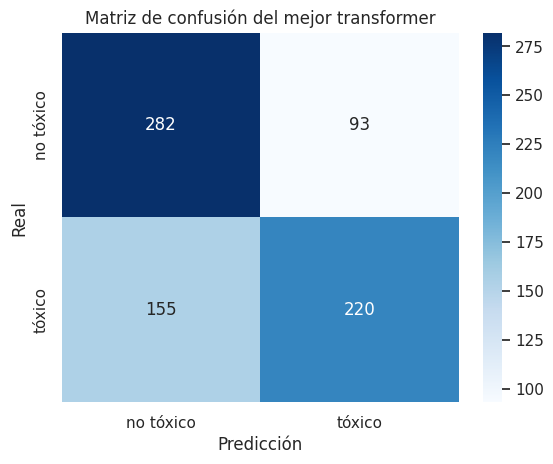

In [17]:
best_model = model_4 if results_df.iloc[0]['modelo'] == '4 cabezas' else model_1
_, _, y_true, y_pred = run_epoch(best_model, test_loader)
print(classification_report(y_true, y_pred, target_names=['no tóxico', 'tóxico'], digits=3))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['no tóxico', 'tóxico'], yticklabels=['no tóxico', 'tóxico'])
plt.xlabel('Predicción'); plt.ylabel('Real'); plt.title('Matriz de confusión del mejor transformer'); plt.show()

In [18]:
best_model.eval()
error_rows = []
with torch.no_grad():
    for batch in test_loader:
        logits = best_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        probabilities = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        predictions = logits.argmax(1).cpu().numpy()
        for text, real, pred, probability in zip(batch['text'], batch['label'].numpy(), predictions, probabilities):
            if real != pred: error_rows.append({'text': text, 'real': real, 'prediccion': pred, 'prob_toxica': probability})
errors = pd.DataFrame(error_rows)
errors['tipo_error'] = np.where(errors['real'].eq(1), 'falso negativo', 'falso positivo')
print('Errores encontrados:', len(errors))
display(errors.sort_values('prob_toxica').head(10))
display(errors.sort_values('prob_toxica', ascending=False).head(10))

Errores encontrados: 248


,text,real,prediccion,prob_toxica,tipo_error
189,"el mal llamado ""matrimonio"" gay atenta contra ...",1,0,0.072701,falso negativo
74,¿Tienes alguna cosa positiva que decir? Eres u...,1,0,0.084871,falso negativo
124,"Está buena la porsini, pero está mal de la cab...",1,0,0.087197,falso negativo
47,Que se muera la reina y toda su puta familia d...,1,0,0.088103,falso negativo
119,termina enseguida enjaulado en la vagina porqu...,1,0,0.094825,falso negativo
120,Grupos como el #NewWorldOrder intentan convenc...,1,0,0.097978,falso negativo
110,"Amenábar es gay, y desde la doble perspectiva ...",1,0,0.098103,falso negativo
191,"Pero: Cada uno de los denunciados puede, para ...",1,0,0.109249,falso negativo
157,El holocuento es una de las mayores manipulaci...,1,0,0.121499,falso negativo
218,La Dra. Chinda Brandolino ha presentado una ca...,1,0,0.123121,falso negativo


,text,real,prediccion,prob_toxica,tipo_error
91,"El respeto no se compra, ni se vende, ni se pu...",0,1,0.895234,falso positivo
141,¿Qué se siente no saber quién eres ni lo que q...,0,1,0.868299,falso positivo
108,Porque Tabasco es un estado digno y trabajador...,0,1,0.859197,falso positivo
56,¿Es responsabilidad de los gobiernos garantiza...,0,1,0.841612,falso positivo
72,Quiero que sepas que no me importa tu religión...,0,1,0.828607,falso positivo
175,pero no tienes ni una puta idea de lo que hay ...,0,1,0.808594,falso positivo
168,¿Qué tienen los suecos que no tengamos nosotro...,0,1,0.805748,falso positivo
25,Fui al otorrino por que note que escuchaba men...,0,1,0.797372,falso positivo
105,Qué pendejo fui al prestarle dinero a ese cabr...,0,1,0.792206,falso positivo
10,lo qe no me guustha es que crean que no son ac...,0,1,0.788061,falso positivo


### Lectura de los errores

Al revisar los casos anteriores debemos buscar ambigüedad, ironía, contexto ausente, insultos usados de forma citada y errores de anotación. Un falso negativo es especialmente relevante para moderación; un falso positivo puede afectar la libertad de expresión. Por ello, el modelo no debería desplegarse como juez autónomo: sus predicciones requieren umbral, revisión y monitoreo.

In [19]:
custom_examples = [
    'No comparto tu opinión, pero respeto tu punto de vista.',
    'Eres un inútil y nadie quiere leerte.',
    'Qué comentario tan brillante, gracias por explicarlo.',
    'Dejen de insultar y discutamos el tema con argumentos.'
]
custom_dataset = ToxicityDataset(pd.DataFrame({'text': custom_examples, 'label_id': [0] * len(custom_examples)}), tokenizer, MAX_LEN)
custom_loader = DataLoader(custom_dataset, batch_size=4)
_, _, _, custom_pred = run_epoch(best_model, custom_loader)
for text, pred in zip(custom_examples, custom_pred):
    label_name = 'tóxico' if pred else 'no tóxico'
    print(f'[{label_name}] {text}')

[no tóxico] No comparto tu opinión, pero respeto tu punto de vista.
[tóxico] Eres un inútil y nadie quiere leerte.
[no tóxico] Qué comentario tan brillante, gracias por explicarlo.
[no tóxico] Dejen de insultar y discutamos el tema con argumentos.


## Análisis complementario: interpretación y umbral de decisión

El desempeño global no explica por sí solo cómo toma decisiones el modelo. Para profundizar el análisis, examinaremos la atención sobre un comentario y mediremos cómo cambia el equilibrio entre precisión y recall cuando modificamos el umbral usado para declarar un comentario como tóxico.

Texto: No, subnormal analfabeto, el tema no es ese
Etiqueta real: tóxico
Predicción: tóxico
Probabilidad de toxicidad: 0.635


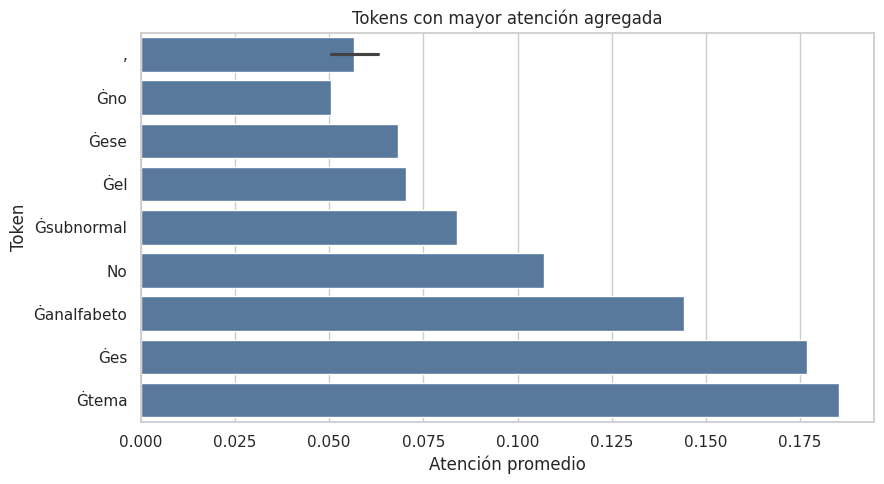

In [20]:
# Interpretación de atención para un comentario del conjunto de prueba.
# Se escoge el primer ejemplo para que el análisis sea reproducible.
example = test_data[0]
input_ids = example['input_ids'].unsqueeze(0).to(device)
attention_mask = example['attention_mask'].unsqueeze(0).to(device)

best_model.eval()
with torch.no_grad():
    logits, attention_weights = best_model(input_ids, attention_mask, return_attention=True)

probability = torch.softmax(logits, dim=1)[0, 1].item()
prediction = int(logits.argmax(dim=1).item())
valid_tokens = attention_mask[0].bool()
tokens = tokenizer.convert_ids_to_tokens(input_ids[0][valid_tokens].cpu().tolist())

# Promediamos cabezas y posiciones de consulta para obtener una importancia aproximada por token.
valid_attention = attention_weights[0][:, valid_tokens, :][:, :, valid_tokens]
token_importance = valid_attention.mean(dim=(0, 1)).cpu().numpy()
top_indices = np.argsort(token_importance)[::-1][:15]

print('Texto:', example['text'])
print('Etiqueta real:', 'tóxico' if example['label'] else 'no tóxico')
print('Predicción:', 'tóxico' if prediction else 'no tóxico')
print(f'Probabilidad de toxicidad: {probability:.3f}')

attention_df = pd.DataFrame({
    'token': [tokens[index] for index in top_indices],
    'importancia': [token_importance[index] for index in top_indices]
}).sort_values('importancia')

plt.figure(figsize=(9, 5))
sns.barplot(data=attention_df, x='importancia', y='token', color='#4c78a8')
plt.title('Tokens con mayor atención agregada')
plt.xlabel('Atención promedio')
plt.ylabel('Token')
plt.tight_layout()
plt.show()

Mejor umbral según F1: 0.30


,umbral,precision,recall,f1
0,0.10,0.516,0.981,0.676
1,0.15,0.539,0.960,0.690
2,0.20,0.572,0.923,0.706
3,0.25,0.589,0.883,0.707
4,0.30,0.616,0.829,0.707
5,0.35,0.635,0.765,0.694
6,0.40,0.658,0.717,0.686
7,0.45,0.682,0.659,0.670
8,0.50,0.703,0.587,0.640
9,0.55,0.716,0.512,0.597


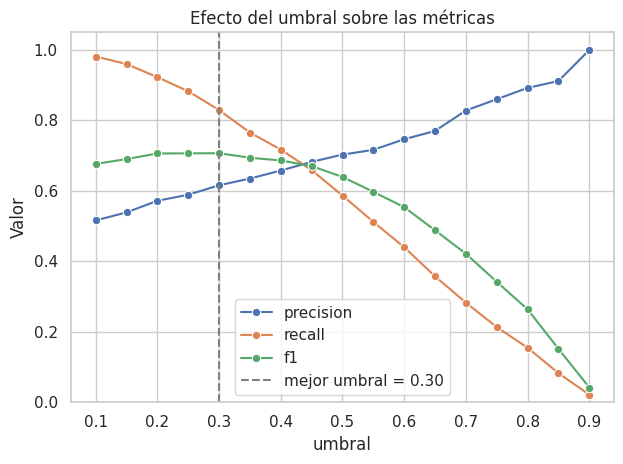

In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Guardamos probabilidades para estudiar distintos umbrales sin reentrenar el modelo.
all_probabilities, all_targets = [], []
best_model.eval()
with torch.no_grad():
    for batch in test_loader:
        logits = best_model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        all_probabilities.extend(torch.softmax(logits, dim=1)[:, 1].cpu().numpy())
        all_targets.extend(batch['label'].numpy())

all_probabilities = np.array(all_probabilities)
all_targets = np.array(all_targets)
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    threshold_predictions = (all_probabilities >= threshold).astype(int)
    threshold_results.append({
        'umbral': threshold,
        'precision': precision_score(all_targets, threshold_predictions, zero_division=0),
        'recall': recall_score(all_targets, threshold_predictions, zero_division=0),
        'f1': f1_score(all_targets, threshold_predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax()]
print(f"Mejor umbral según F1: {best_threshold['umbral']:.2f}")
display(threshold_df.round(3))

threshold_plot = threshold_df.melt(id_vars='umbral', value_vars=['precision', 'recall', 'f1'], var_name='métrica', value_name='valor')
sns.lineplot(data=threshold_plot, x='umbral', y='valor', hue='métrica', marker='o')
plt.axvline(best_threshold['umbral'], color='gray', linestyle='--', label=f"mejor umbral = {best_threshold['umbral']:.2f}")
plt.ylim(0, 1.05)
plt.title('Efecto del umbral sobre las métricas')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

- El EDA permite verificar el balance, la longitud y las señales superficiales antes de atribuir el resultado a la arquitectura.
- El baseline TF-IDF establece una referencia interpretable; el transformer debe compararse contra ella y no evaluarse de forma aislada.
- El número de cabezas modifica la capacidad de atención, pero más cabezas no garantizan mejor desempeño en un corpus pequeño.
- Los falsos positivos y falsos negativos muestran que la toxicidad depende del contexto, la ironía y la intención; una predicción binaria simplifica un fenómeno social complejo.
- El modelo entrenado desde cero es útil para comprender el mecanismo, pero un sistema productivo requeriría más datos, evaluación por grupos lingüísticos, calibración de umbrales y comparación con modelos preentrenados en español.

## Reproducibilidad

Este experimento puede repetirse en Google Colab siguiendo el orden de las celdas del notebook y ejecutando primero la instalación de dependencias. Los resultados pueden variar ligeramente entre ejecuciones si cambia la versión de las librerías o el hardware disponible.

### Configuración registrada

- **Fuente de datos:** `textdetox/multilingual_toxicity_dataset`, configuración `es`.
- **Preprocesamiento:** eliminación de textos vacíos, normalización de espacios y eliminación de duplicados.
- **División:** 70% entrenamiento, 15% validación y 15% prueba, con estratificación y `random_state=42`.
- **Tokenizador:** Byte-Level BPE entrenado con los textos de entrenamiento, vocabulario de 12.000 tokens y longitud máxima de 128 tokens.
- **Modelo:** embeddings de tamaño 96, positional encoding sinusoidal, una capa transformer, `GELU`, dropout de 0.15 en el bloque y dropout de 0.2 en el clasificador.
- **Experimentos:** una cabeza y cuatro cabezas de atención.
- **Entrenamiento:** AdamW, learning rate `2e-4`, weight decay `1e-4`, cuatro épocas, clipping de gradiente a 1.0 y semilla de PyTorch `42`.
- **Criterio principal:** F1 de la clase tóxica en el conjunto de prueba, acompañado de precisión, recall, accuracy y matriz de confusión.

### Secuencia para repetirlo

1. Ejecutar la instalación de dependencias y la carga de datos.
2. Ejecutar el EDA y la división estratificada.
3. Entrenar el tokenizador y crear los `DataLoader`.
4. Entrenar las variantes de una y cuatro cabezas.
5. Comparar los resultados, seleccionar el mejor modelo y revisar sus errores.

La semilla controla la inicialización de los modelos y las divisiones principales; aun así, el uso de GPU puede producir pequeñas diferencias numéricas entre ejecuciones. Por eso se reportan las métricas con tres decimales y se recomienda conservar la versión de Colab y de las librerías al comparar resultados.